In [1]:
import pandas as pd
import numpy as np

# --- Step 1: Load Data ---
df = pd.read_csv("/Users/anamikasaroha/Energy7/week_10/NFR_poll_100.csv")

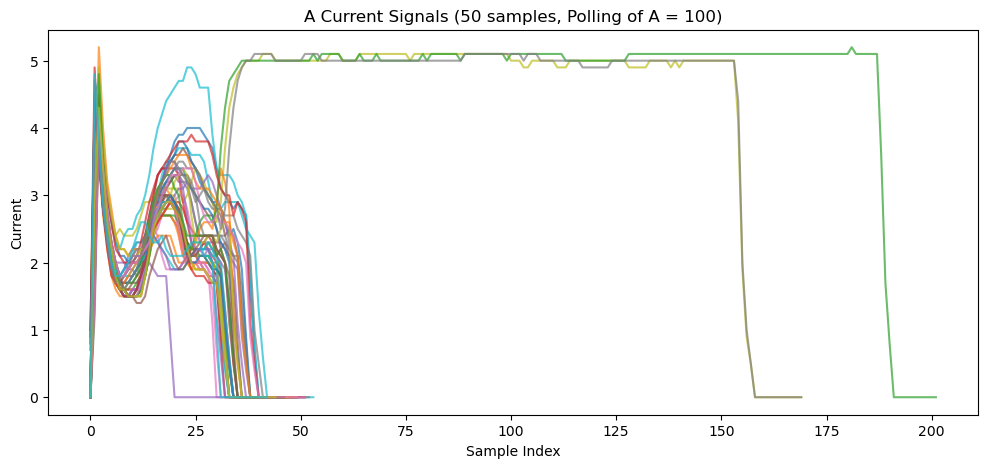

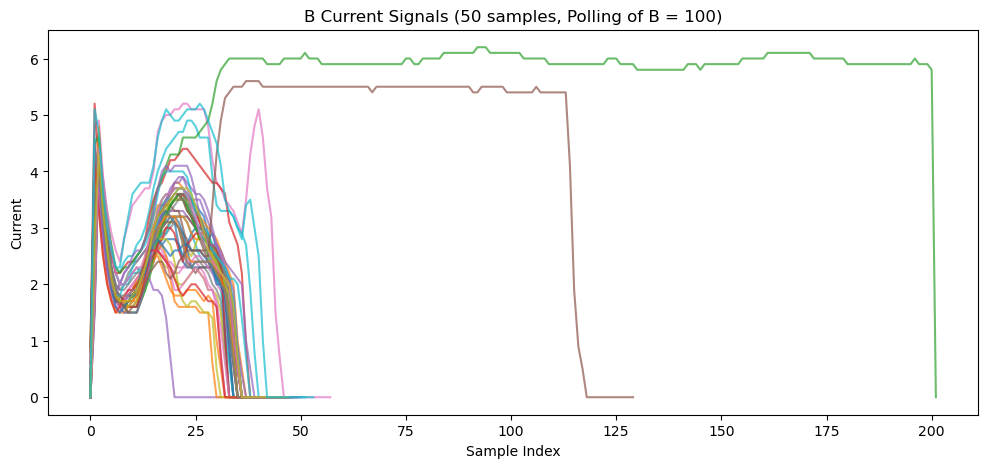

In [3]:
import matplotlib.pyplot as plt

# Filter for Polling of A = 100
df_poll_100 = df[df["Polling of A"] == 100]

# Sample 50 rows from each

sample_100 = df_poll_100.sample(n=50, random_state=42)

# Plot for Polling of A = 100
plt.figure(figsize=(12, 5))
for idx, row in sample_100.iterrows():
    signal = [float(x.strip()) for x in row["A Current"].split(",")]
    plt.plot(signal, alpha=0.7)
plt.title("A Current Signals (50 samples, Polling of A = 100)")
plt.xlabel("Sample Index")
plt.ylabel("Current")
plt.show()

# Plot for Polling of B = 100 
plt.figure(figsize=(12, 5))
for idx, row in sample_100.iterrows():
    signal = [float(x.strip()) for x in row["B Current"].split(",")]
    plt.plot(signal, alpha=0.7)
plt.title("B Current Signals (50 samples, Polling of B = 100)")
plt.xlabel("Sample Index")
plt.ylabel("Current")
plt.show()


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def parse_signal_data(signal_string):
    """Parse comma-separated signal data string into numpy array"""
    try:
        values = [float(x) for x in signal_string.split(',')]
        return np.array(values)
    except:
        return np.array([])

def get_signal_length(signal_array):
    """Get the length of non-zero signal (excluding trailing zeros)"""
    # Find the last non-zero value
    non_zero_indices = np.where(signal_array > 0)[0]
    if len(non_zero_indices) == 0:
        return 0
    return non_zero_indices[-1] + 1

def is_signal_normal(signal_array, max_value_threshold=5.0, max_length=50):
    """
    Check if a signal is normal based on:
    1. Maximum value threshold
    2. Signal length
    3. Signal variation (to detect flat/straight lines)
    """
    if len(signal_array) == 0:
        return False
    
    # Check maximum value
    if np.max(signal_array) > max_value_threshold:
        return False
    
    # Check signal length (non-zero portion)
    signal_length = get_signal_length(signal_array)
    if signal_length > max_length:
        return False
    
    # Check if signal has reasonable variation (not a flat line)
    # Get non-zero portion of signal
    non_zero_signal = signal_array[signal_array > 0]
    if len(non_zero_signal) < 3:  # Too short to analyze
        return False
    
    # Calculate standard deviation of non-zero values
    signal_std = np.std(non_zero_signal)
    signal_mean = np.mean(non_zero_signal)
    
    # If coefficient of variation is too low, it might be a flat line
    if signal_mean > 0:
        cv = signal_std / signal_mean
        if cv < 0.1:  # Less than 10% variation
            return False
    
    return True


In [5]:
def filter_signal_data(csv_file_path, output_file_path=None):
    """
    Filter the CSV file to keep only normal signals
    """
    # Read the CSV file
    df = pd.read_csv(csv_file_path)
    
    print(f"Original dataset shape: {df.shape}")
    
    # Create a mask for normal signals
    normal_mask = []
    
    for index, row in df.iterrows():
        # Parse current signals
        a_current = parse_signal_data(row['A Current'])
        b_current = parse_signal_data(row['B Current'])
        
        # Check if both A and B currents are normal
        a_normal = is_signal_normal(a_current)
        b_normal = is_signal_normal(b_current)
        
        # Keep row only if both signals are normal
        is_normal = a_normal and b_normal
        normal_mask.append(is_normal)
        
        if not is_normal:
            print(f"Removing row {index}: A_max={np.max(a_current):.1f}, B_max={np.max(b_current):.1f}, "
                  f"A_len={get_signal_length(a_current)}, B_len={get_signal_length(b_current)}")
    
    # Filter the dataframe
    filtered_df = df[normal_mask].copy()
    
    print(f"Filtered dataset shape: {filtered_df.shape}")
    print(f"Removed {len(df) - len(filtered_df)} rows")
    
    # Save filtered data
    if output_file_path is None:
        output_file_path = csv_file_path.replace('.csv', '_filtered.csv')
    
    filtered_df.to_csv(output_file_path, index=False)
    print(f"Filtered data saved to: {output_file_path}")
    
    return filtered_df


In [6]:
def plot_filtered_signals(df, max_plots=10):
    """
    Plot the first few filtered signals to verify filtering
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    count = 0
    for index, row in df.iterrows():
        if count >= max_plots:
            break
            
        a_current = parse_signal_data(row['A Current'])
        b_current = parse_signal_data(row['B Current'])
        
        ax1.plot(a_current, alpha=0.7, label=f'Row {index}')
        ax2.plot(b_current, alpha=0.7, label=f'Row {index}')
        
        count += 1
    
    ax1.set_title('Filtered A Current Signals')
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('Current')
    ax1.grid(True)
    
    ax2.set_title('Filtered B Current Signals')
    ax2.set_xlabel('Sample Index')
    ax2.set_ylabel('Current')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()


Original dataset shape: (6397, 12)
Removing row 10: A_max=4.1, B_max=6.1, A_len=38, B_len=47
Removing row 54: A_max=4.1, B_max=5.4, A_len=36, B_len=117
Removing row 58: A_max=4.1, B_max=5.5, A_len=37, B_len=117
Removing row 73: A_max=4.2, B_max=5.3, A_len=37, B_len=116
Removing row 87: A_max=4.6, B_max=4.3, A_len=18, B_len=36
Removing row 99: A_max=5.8, B_max=4.4, A_len=48, B_len=35
Removing row 100: A_max=5.2, B_max=4.0, A_len=117, B_len=34
Removing row 103: A_max=5.3, B_max=4.1, A_len=115, B_len=34
Removing row 106: A_max=4.2, B_max=6.1, A_len=38, B_len=116
Removing row 107: A_max=5.2, B_max=4.0, A_len=117, B_len=34
Removing row 108: A_max=3.8, B_max=5.7, A_len=37, B_len=116
Removing row 112: A_max=3.9, B_max=5.6, A_len=37, B_len=116
Removing row 113: A_max=3.8, B_max=5.6, A_len=37, B_len=116
Removing row 120: A_max=4.0, B_max=5.7, A_len=36, B_len=117
Removing row 123: A_max=5.3, B_max=4.0, A_len=117, B_len=34
Removing row 124: A_max=5.9, B_max=4.4, A_len=117, B_len=35
Removing row 1

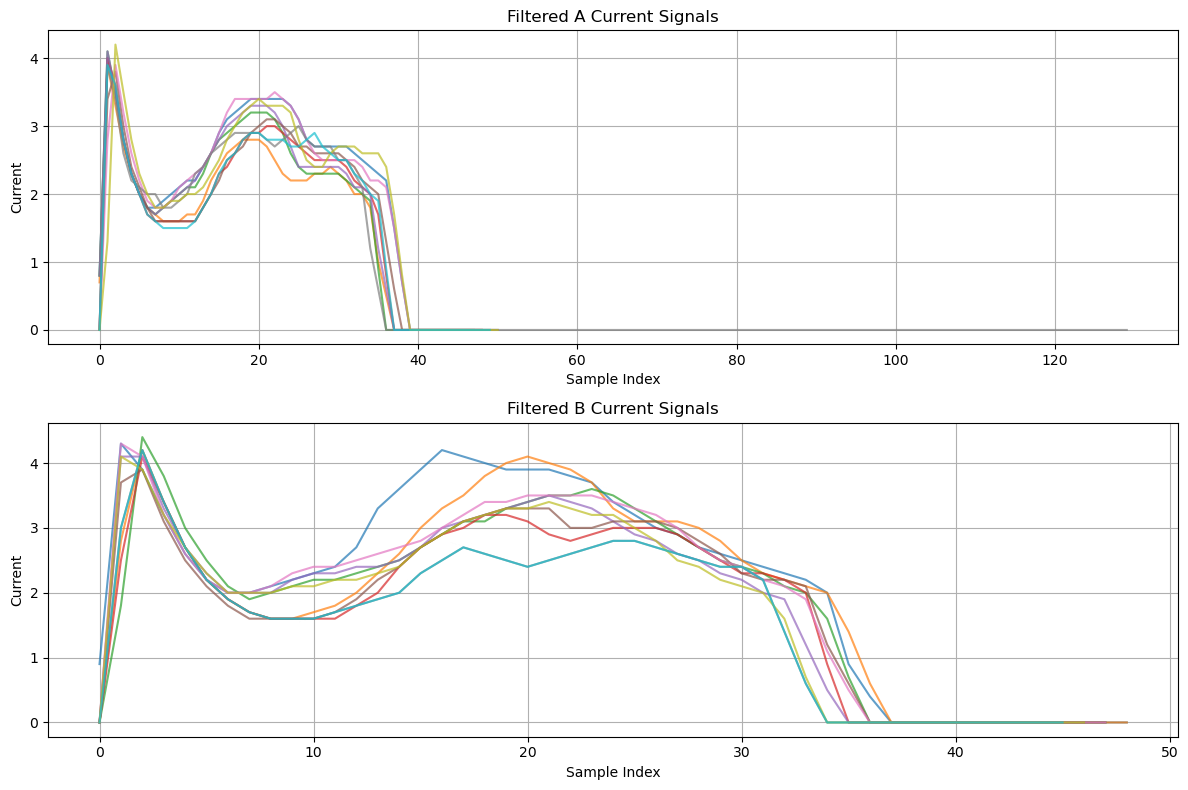


Filtered dataset statistics:
Row 0: A_max=4.0, B_max=4.3, A_len=39, B_len=37
Row 1: A_max=3.9, B_max=4.2, A_len=37, B_len=37
Row 2: A_max=4.1, B_max=4.4, A_len=36, B_len=36
Row 3: A_max=4.0, B_max=4.1, A_len=37, B_len=35
Row 4: A_max=4.1, B_max=4.1, A_len=37, B_len=35
Row 5: A_max=3.8, B_max=3.9, A_len=38, B_len=36
Row 6: A_max=3.9, B_max=4.3, A_len=39, B_len=36
Row 7: A_max=3.9, B_max=4.2, A_len=36, B_len=34
Row 8: A_max=4.2, B_max=4.1, A_len=39, B_len=34
Row 9: A_max=3.9, B_max=4.2, A_len=37, B_len=34
Row 11: A_max=4.0, B_max=4.3, A_len=38, B_len=35
Row 12: A_max=3.9, B_max=4.0, A_len=37, B_len=34
Row 13: A_max=3.9, B_max=4.1, A_len=37, B_len=34
Row 14: A_max=3.9, B_max=4.3, A_len=38, B_len=34
Row 15: A_max=3.8, B_max=4.3, A_len=36, B_len=34
Row 16: A_max=4.1, B_max=4.2, A_len=38, B_len=35
Row 17: A_max=3.9, B_max=4.4, A_len=38, B_len=35
Row 18: A_max=3.8, B_max=4.1, A_len=37, B_len=34
Row 19: A_max=3.9, B_max=4.4, A_len=37, B_len=35
Row 20: A_max=4.0, B_max=4.2, A_len=38, B_len=36


In [7]:
# Main execution
if __name__ == "__main__":
    
    csv_file_path = '/Users/anamikasaroha/Energy7/week_10/NFR_poll_100.csv'
    
    # Filter the data
    filtered_df = filter_signal_data(csv_file_path)
    
    # Plot the filtered signals to verify
    plot_filtered_signals(filtered_df)
    
    # Additional statistics
    print("\nFiltered dataset statistics:")
    for index, row in filtered_df.iterrows():
        a_current = parse_signal_data(row['A Current'])
        b_current = parse_signal_data(row['B Current'])
        
        print(f"Row {index}: A_max={np.max(a_current):.1f}, B_max={np.max(b_current):.1f}, "
              f"A_len={get_signal_length(a_current)}, B_len={get_signal_length(b_current)}")

## separating Current A and Current B 

In [9]:
import pandas as pd
import ast

# Load the dataset
df = pd.read_csv(r"/Users/anamikasaroha/Energy7/week_10/NFR_poll_100_filtered.csv")

# Convert stringified lists into actual Python lists
def parse_list(col):
    return col.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df['A Current'] = parse_list(df['A Current'])
df['B Current'] = parse_list(df['B Current'])
df['A Voltage'] = parse_list(df['A Voltage'])
df['B Voltage'] = parse_list(df['B Voltage'])

# New list for melted rows
rows = []

# Process each row
for _, row in df.iterrows():
    original_pm = row['Point Machine Name']
    
    if '/' in original_pm:
        # Example: PT-101/102 → PT-101 and PT-102
        prefix = original_pm.split('/')[0].split('-')[0] + '-'
        part_a = prefix + original_pm.split('/')[0].split('-')[-1]
        part_b = prefix + original_pm.split('/')[1]
    else:
        # Example: PT76 → PT76A and PT76B
        part_a = original_pm + 'A'
        part_b = original_pm + 'B'

    # A side
    rows.append({
        'Time': row['Time'],
        'Site Name': row['Site Name'],
        'Direction': row['Direction'],
        'Original Point Machine Name': original_pm,
        'Point Machine': part_a,
        'Current': row['A Current'],
        'Voltage': row['A Voltage'],
    })

    # B side
    rows.append({
        'Time': row['Time'],
        'Site Name': row['Site Name'],
        'Direction': row['Direction'],
        'Original Point Machine Name': original_pm,
        'Point Machine': part_b,
        'Current': row['B Current'],
        'Voltage': row['B Voltage'],
    })

# Create final melted DataFrame
melted_df = pd.DataFrame(rows)

# Save to CSV
melted_df.to_csv("melted_ptmachines_NFR_100.csv", index=False)

In [11]:
df_new = pd.read_csv("melted_ptmachines_NFR_100.csv")
df_new.head()

,Time,Site Name,Direction,Original Point Machine Name,Point Machine,Current,Voltage
0,2025-06-12 10:58:23,NALBARI,Reverse,PT-101/102,PT-101,"(0.8, 4.0, 3.5, 2.8, 2.3, 2.0, 1.8, 1.8, 1.9, ...","(0.0, 19.5, 58.5, 82.5, 96.0, 102.0, 106.5, 10..."
1,2025-06-12 10:58:23,NALBARI,Reverse,PT-101/102,PT-102,"(0.9, 4.3, 3.9, 3.2, 2.6, 2.2, 2.0, 2.0, 2.1, ...","(0.0, 18.0, 55.5, 81.0, 94.5, 102.0, 106.5, 10..."
2,2025-06-12 11:03:48,NALBARI,Normal,PT-101/102,PT-101,"(0.7, 3.9, 3.3, 2.7, 2.3, 2.0, 1.8, 1.7, 1.6, ...","(0.0, 33.0, 67.5, 88.5, 97.5, 103.5, 106.5, 10..."
3,2025-06-12 11:03:48,NALBARI,Normal,PT-101/102,PT-102,"(0.0, 2.8, 4.2, 3.4, 2.7, 2.2, 1.9, 1.7, 1.6, ...","(0.0, 31.5, 64.5, 87.0, 97.5, 103.5, 108.0, 10..."
4,2024-12-12 10:44:54,NALBARI,Reverse,PT-101/102,PT-101,"(0.8, 4.1, 3.5, 2.8, 2.3, 2.0, 1.8, 1.7, 1.8, ...","(0.0, 25.5, 61.5, 85.5, 97.5, 103.5, 106.5, 10..."


In [12]:
df_new.shape

(9816, 7)